In [1]:
%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

from config import TEMPLATES_DIR, INPUT_DIR, OUTPUT_DIR
from utils import detect_and_align, alignment_error

# --- что обрабатываем ---
CHAR_ID = "003"
PHOTO_NAME = "003_test3.jpg"

# --- derived ---
CHAR_DIR = TEMPLATES_DIR / CHAR_ID
PHOTO_PATH = INPUT_DIR / PHOTO_NAME
STEM = Path(PHOTO_NAME).stem

BL marker = 3 (ожидали 5), alignment error = 5.26 px — плохо — перефоткай


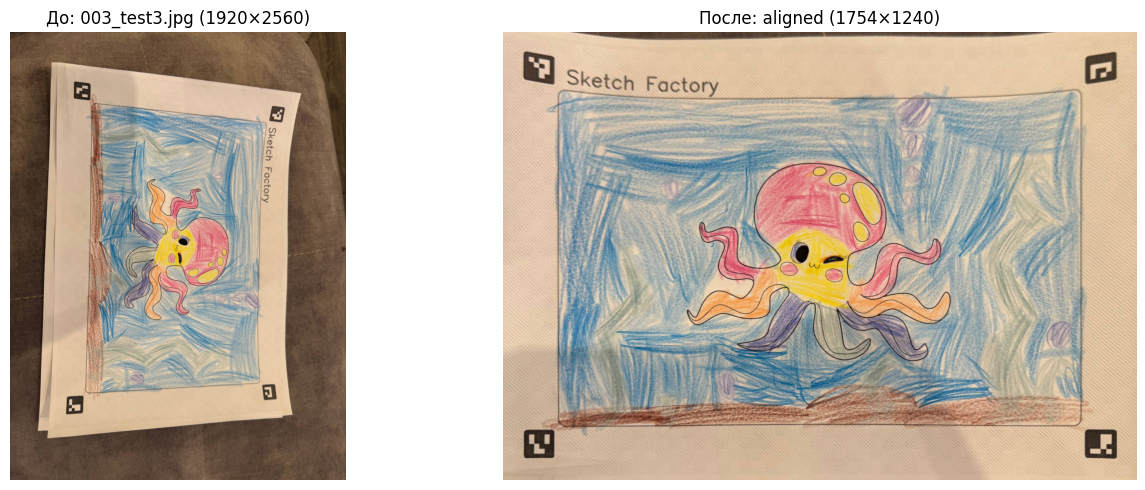

In [2]:
# Прогон алгоритма
result = detect_and_align(str(PHOTO_PATH))
aligned = result["aligned"]
bl_id = result["bl_id"]
err, _ = alignment_error(aligned)

quality = "отлично" if err < 1 else "хорошо" if err < 3 else "плохо — перефоткай"
print(f"BL marker = {bl_id} (ожидали {int(CHAR_ID)+2}), alignment error = {err:.2f} px — {quality}")

# Визуал до/после
original = cv2.imread(str(PHOTO_PATH))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].axis("off")
axes[0].set_title(f"До: {PHOTO_NAME} ({original.shape[1]}×{original.shape[0]})")

axes[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
axes[1].axis("off")
axes[1].set_title(f"После: aligned ({aligned.shape[1]}×{aligned.shape[0]})")
plt.tight_layout(); plt.show()


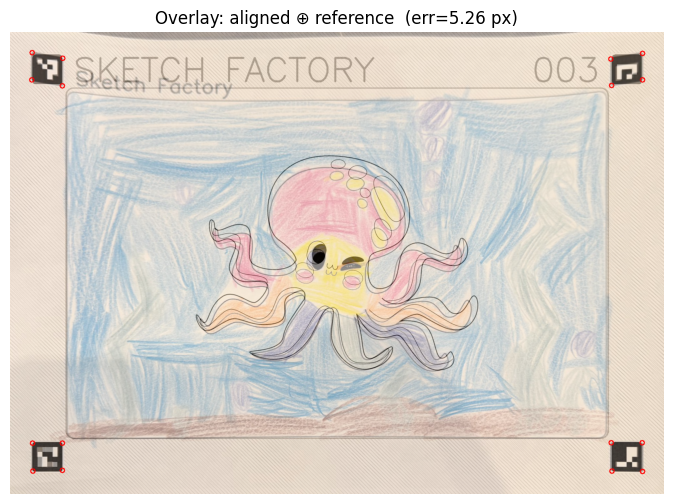

In [3]:
# Контрольный overlay: aligned ⊕ reference (50/50 blend)
# Если маркеры двоятся — warp кривой. Если чёткие — всё ок.
ref = cv2.imread(str(CHAR_DIR / "template.png"))
blend = cv2.addWeighted(aligned, 0.5, ref, 0.5, 0)

# Детектированные углы маркеров на aligned (красные точки)
from utils import ARUCO_DICT
detector = cv2.aruco.ArucoDetector(cv2.aruco.getPredefinedDictionary(ARUCO_DICT))
corners, _, _ = detector.detectMarkers(aligned)
annotated = blend.copy()
for c in corners:
    for pt in c[0]:
        cv2.circle(annotated, tuple(pt.astype(int)), 6, (0, 0, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Overlay: aligned ⊕ reference  (err={err:.2f} px)")
plt.show()

In [4]:
out_path = OUTPUT_DIR / f"stage2_aligned_{STEM}.png"
cv2.imwrite(str(out_path), aligned)
print(f"Сохранено: {out_path}")

Сохранено: C:\Users\Luga\Documents\GitHub\ink-to-motion\dev\pipeline\output\stage2_aligned_003_test3.png
